# Khám phá dữ liệu chất lượng không khí Hoàn Kiếm (2022–2025)

Quy trình: đọc dữ liệu → khảo sát ban đầu → đánh giá chất lượng → xử lý trên bản sao → kiểm tra sau xử lý → trực quan hóa và rút ra insight.

In [21]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 1. Đọc dữ liệu và lưu bản gốc

In [22]:
DATA_PATH = Path("data/raw/data2225.csv")
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()
print(f"Kích thước dữ liệu gốc: {df.shape[0]:,} dòng × {df.shape[1]} cột")
display(df.head())

Kích thước dữ liệu gốc: 34,759 dòng × 19 cột


,Local Time,UTC Time,City,Country Code,Timezone,AQI,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,UV Index,Wind Speed
0,1/13/2022 7:00,1/13/2022 0:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,61,353.1,10.0,84.0,98.0,17.08,52.0,100,0.00,1020,95,15.5,0.6,2.00
1,1/13/2022 8:00,1/13/2022 1:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,61,343.5,9.0,87.3,95.7,16.75,48.7,91,0.00,1021,94,15.4,0.7,2.33
2,1/13/2022 9:00,1/13/2022 2:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,60,334.0,8.0,90.7,93.3,16.42,45.3,83,0.50,1022,93,15.3,1.0,2.66
3,1/13/2022 10:00,1/13/2022 3:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,59,324.5,7.0,94.0,91.0,16.09,42.0,75,0.75,1022,93,15.2,1.5,3.00
4,1/13/2022 11:00,1/13/2022 4:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,60,319.6,6.7,95.7,91.3,16.17,39.0,83,0.00,1021,87,15.6,1.9,3.00


## 2. Khảo sát dữ liệu ban đầu

Sử dụng `info()`, `nunique()` và `describe()` để tìm hiểu cấu trúc, kiểu dữ liệu và phạm vi giá trị.

In [23]:
df.info()

structure_report = pd.DataFrame({
    "Kiểu dữ liệu": df.dtypes.astype(str),
    "Không thiếu": df.notna().sum(),
    "Thiếu": df.isna().sum(),
    "Số giá trị khác nhau": df.nunique(dropna=True),
})
display(structure_report)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34759 entries, 0 to 34758
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Local Time         34759 non-null  object 
 1   UTC Time           34759 non-null  object 
 2   City               34759 non-null  object 
 3   Country Code       34759 non-null  object 
 4   Timezone           34759 non-null  object 
 5   AQI                34759 non-null  int64  
 6   CO                 34685 non-null  float64
 7   NO2                34685 non-null  float64
 8   O3                 34685 non-null  float64
 9   PM10               34757 non-null  float64
 10  PM25               34757 non-null  float64
 11  SO2                34685 non-null  float64
 12  Clouds             34759 non-null  int64  
 13  Precipitation      34759 non-null  float64
 14  Pressure           34759 non-null  int64  
 15  Relative Humidity  34759 non-null  int64  
 16  Temperature        347

,Kiểu dữ liệu,Không thiếu,Thiếu,Số giá trị khác nhau
Local Time,object,34759,0,34751
UTC Time,object,34759,0,34751
City,object,34759,0,1
Country Code,object,34759,0,1
Timezone,object,34759,0,1
AQI,int64,34759,0,219
CO,float64,34685,74,9052
NO2,float64,34685,74,2460
O3,float64,34685,74,1412
PM10,float64,34757,2,3922


In [24]:
df["Local Time"] = pd.to_datetime(df["Local Time"], errors="coerce")
id_cols = ["Local Time", "UTC Time", "City", "Country Code", "Timezone"]
measurement_cols = [col for col in df.columns if col not in id_cols]
df[measurement_cols] = df[measurement_cols].apply(pd.to_numeric, errors="coerce")
display(df[measurement_cols].describe().T.round(2))

,count,mean,std,min,25%,50%,75%,max
AQI,34759.0,65.83,35.31,0.00,41.00,60.00,80.00,500.0
CO,34685.0,524.27,842.69,0.00,126.10,196.10,504.00,15956.2
NO2,34685.0,18.33,22.17,0.00,6.30,11.00,21.84,624.0
O3,34685.0,54.68,42.72,0.00,23.70,45.00,75.00,700.0
PM10,34757.0,42.79,43.98,0.48,19.00,30.38,51.00,604.0
PM25,34757.0,21.14,17.60,0.48,9.90,16.50,26.00,274.2
SO2,34685.0,36.31,35.10,0.00,13.44,29.82,49.00,432.6
Clouds,34759.0,68.49,32.86,0.00,45.00,78.00,100.00,100.0
Precipitation,34759.0,0.31,1.14,0.00,0.00,0.00,0.00,40.0
Pressure,34759.0,1009.91,7.19,983.00,1004.00,1010.00,1015.00,1033.0


## 3. Đánh giá chất lượng dữ liệu gốc

In [25]:
missing_report = pd.DataFrame({
    "Số giá trị thiếu": df.isna().sum(),
    "Tỷ lệ thiếu (%)": df.isna().mean().mul(100),
}).sort_values("Tỷ lệ thiếu (%)", ascending=False)
display(missing_report.round(3))

,Số giá trị thiếu,Tỷ lệ thiếu (%)
CO,74,0.213
NO2,74,0.213
O3,74,0.213
SO2,74,0.213
PM10,2,0.006
PM25,2,0.006
Clouds,0,0.000
UV Index,0,0.000
Temperature,0,0.000
Relative Humidity,0,0.000


In [26]:
duplicate_full = int(df.duplicated().sum())
duplicate_mask = df["Local Time"].duplicated(keep=False)
duplicate_timestamp_count = int(df.loc[duplicate_mask, "Local Time"].nunique())
duplicate_extra_rows = int(df["Local Time"].duplicated().sum())
print("Số dòng trùng hoàn toàn:", duplicate_full)
print("Số timestamp có nhiều bản ghi:", duplicate_timestamp_count)
print("Số bản ghi dư do trùng timestamp:", duplicate_extra_rows)
duplicate_time_rows = df.loc[duplicate_mask].sort_values("Local Time")
display(duplicate_time_rows)

Số dòng trùng hoàn toàn: 0
Số timestamp có nhiều bản ghi: 8
Số bản ghi dư do trùng timestamp: 8


,Local Time,UTC Time,City,Country Code,Timezone,AQI,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,UV Index,Wind Speed
18665,2024-03-01,2/29/2024 17:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,16,216.0,6.25,33.7,3.75,3.75,17.90,100,0.00,1020,69,14.5,0.0,2.00
18666,2024-03-01,2/29/2024 17:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,16,216.0,6.25,27.8,3.75,3.75,19.20,100,0.00,1020,71,14.2,0.0,2.00
19410,2024-04-01,3/31/2024 17:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,84,214.0,9.25,29.2,41.50,27.75,10.00,0,0.00,1002,92,25.6,0.0,2.00
19411,2024-04-01,3/31/2024 17:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,84,214.0,9.25,29.2,41.50,27.75,15.15,0,0.00,1001,94,24.8,0.0,1.60
24547,2024-11-01,10/31/2024 17:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,161,454.8,12.31,27.3,93.45,74.76,50.27,0,0.00,1009,97,23.7,0.0,1.20
24548,2024-11-01,10/31/2024 17:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,161,1464.7,8.69,18.6,93.45,74.76,34.02,0,0.00,1009,97,23.3,0.0,1.20
25268,2024-12-01,11/30/2024 17:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,84,164.4,8.11,63.7,29.95,28.00,27.85,91,0.00,1013,92,16.4,0.0,0.80
25269,2024-12-01,11/30/2024 17:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,89,164.4,8.11,63.7,34.02,30.38,27.85,92,0.00,1013,94,15.8,0.0,0.80
28882,2025-05-01,4/30/2025 17:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,90,393.7,18.50,32.1,38.15,30.50,144.00,100,0.50,1011,91,26.5,0.0,1.00
28883,2025-05-01,4/30/2025 17:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,90,230.7,18.50,36.7,38.15,30.50,36.85,100,0.50,1011,91,26.5,0.0,1.00


In [27]:
# Tính liên tục của chuỗi thời gian
valid_times = df["Local Time"].dropna().sort_values()
expected_time = pd.date_range(valid_times.min(), valid_times.max(), freq="h")
missing_time = expected_time.difference(pd.DatetimeIndex(valid_times.unique()))
print("Thời điểm bắt đầu:", valid_times.min())
print("Thời điểm kết thúc:", valid_times.max())
print("Số mốc giờ bị thiếu:", len(missing_time))
display(pd.DataFrame({"Timestamp bị thiếu": missing_time}))

Thời điểm bắt đầu: 2022-01-13 07:00:00
Thời điểm kết thúc: 2025-12-31 23:00:00
Số mốc giờ bị thiếu: 18


,Timestamp bị thiếu
0,2024-12-31 20:00:00
1,2024-12-31 21:00:00
2,2024-12-31 22:00:00
3,2024-12-31 23:00:00
4,2025-01-01 00:00:00
5,2025-01-01 01:00:00
6,2025-01-01 02:00:00
7,2025-01-01 03:00:00
8,2025-01-01 04:00:00
9,2025-01-01 05:00:00


## 4. Xử lý dữ liệu

Các phép đo số tại cùng timestamp được lấy trung bình. Chuỗi được tái lập theo giờ và chỉ nội suy khoảng thiếu nằm giữa hai quan sát, dài tối đa 3 giờ. Cột `WasInserted` giúp truy vết timestamp được bổ sung.

In [ ]:
df_clean = df.dropna(subset=["Local Time"]).copy()
numeric_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
text_cols = [c for c in df_clean.columns if c not in numeric_cols + ["Local Time"]]
aggregation = {c: "mean" for c in numeric_cols}
aggregation.update({c: "first" for c in text_cols})
df_clean = (df_clean.groupby("Local Time", as_index=False).agg(aggregation).sort_values("Local Time").set_index("Local Time"))
original_index = df_clean.index.copy()
df_clean = df_clean.asfreq("h")
df_clean["WasInserted"] = ~df_clean.index.isin(original_index)
numeric_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
df_clean[numeric_cols] = df_clean[numeric_cols].interpolate(
    method="time", limit=3, limit_area="inside"
)
text_cols = [c for c in text_cols if c in df_clean.columns]
df_clean[text_cols] = df_clean[text_cols].ffill().bfill()
df_clean = df_clean.reset_index()
display(df_clean.loc[df_clean["WasInserted"]].head(20))

,Local Time,AQI,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,UV Index,Wind Speed,UTC Time,City,Country Code,Timezone,WasInserted
26005,2024-12-31 20:00:00,121.5,2146.4250,6.733333,4.3500,56.276667,43.903333,16.111667,7.0,0.0,1017.916667,93.416667,14.516667,0.1000,1.9,12/31/2024 12:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,True
26006,2024-12-31 21:00:00,119.0,1974.8500,7.166667,6.5000,55.433333,42.866667,18.783333,12.0,0.0,1017.833333,92.833333,15.033333,0.2000,1.8,12/31/2024 12:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,True
26007,2024-12-31 22:00:00,116.5,1803.2750,7.600000,8.6500,54.590000,41.830000,21.455000,17.0,0.0,1017.750000,92.250000,15.550000,0.3000,1.7,12/31/2024 12:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,True
26008,2024-12-31 23:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12/31/2024 12:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,True
26009,2025-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12/31/2024 12:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,True
26010,2025-01-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12/31/2024 12:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,True
26011,2025-01-01 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12/31/2024 12:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,True
26012,2025-01-01 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12/31/2024 12:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,True
26013,2025-01-01 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12/31/2024 12:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,True
26014,2025-01-01 05:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12/31/2024 12:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,True


## 5. Kiểm tra và so sánh sau xử lý

In [29]:
expected_after = pd.date_range(df_clean["Local Time"].min(), df_clean["Local Time"].max(), freq="h")
quality_summary = pd.DataFrame({
    "Chỉ tiêu": ["Số dòng", "Dòng trùng hoàn toàn", "Bản ghi dư do trùng timestamp", "Timestamp bị thiếu", "Giá trị thiếu"],
    "Trước xử lý": [len(df), duplicate_full, duplicate_extra_rows, len(missing_time), int(df.isna().sum().sum())],
    "Sau xử lý": [len(df_clean), int(df_clean.duplicated().sum()), int(df_clean["Local Time"].duplicated().sum()), len(expected_after.difference(df_clean["Local Time"])), int(df_clean.drop(columns="WasInserted").isna().sum().sum())],
})
# Bảng trên dùng để đối chiếu khi cần. Phần dưới in kết quả ngắn gọn.
print("KẾT QUẢ SAU XỬ LÝ")
print("Số dòng:", len(df_clean))
print("Số timestamp trùng:", df_clean["Local Time"].duplicated().sum())
print("Số timestamp còn thiếu:", len(expected_after.difference(df_clean["Local Time"])))
print("Tổng số giá trị còn thiếu:", df_clean.drop(columns="WasInserted").isna().sum().sum())
print("Các cột còn thiếu:")
print(df_clean.drop(columns="WasInserted").isna().sum()[lambda x: x > 0])
print("Số timestamp được bổ sung:", int(df_clean["WasInserted"].sum()))

KẾT QUẢ SAU XỬ LÝ
Số dòng: 34769
Số timestamp trùng: 0
Số timestamp còn thiếu: 0
Tổng số giá trị còn thiếu: 452
Các cột còn thiếu:
AQI                  12
CO                   83
NO2                  83
O3                   83
PM10                 12
PM25                 12
SO2                  83
Clouds               12
Precipitation        12
Pressure             12
Relative Humidity    12
Temperature          12
UV Index             12
Wind Speed           12
dtype: int64
Số timestamp được bổ sung: 18


## 6. Phân bố PM2.5

,count,mean,std,min,25%,50%,75%,max,median,skew
PM25,34757.0,21.15,17.61,0.48,9.9,16.5,26.0,274.2,16.5,2.78


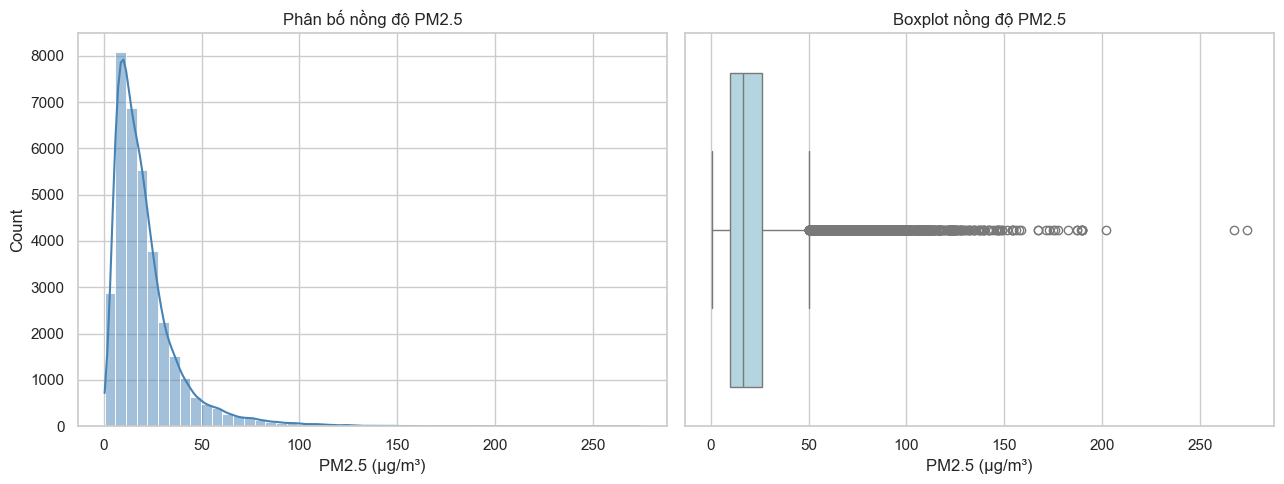

In [30]:
pm25_summary = df_clean["PM25"].describe().to_frame("PM25").T
pm25_summary["median"] = df_clean["PM25"].median()
pm25_summary["skew"] = df_clean["PM25"].skew()
display(pm25_summary.round(2))
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(df_clean["PM25"].dropna(), bins=50, kde=True, ax=axes[0], color="steelblue")
axes[0].set(title="Phân bố nồng độ PM2.5", xlabel="PM2.5 (µg/m³)")
sns.boxplot(x=df_clean["PM25"].dropna(), ax=axes[1], color="lightblue")
axes[1].set(title="Boxplot nồng độ PM2.5", xlabel="PM2.5 (µg/m³)")
plt.tight_layout(); plt.show()

## 7. Biến động PM2.5 theo thời gian

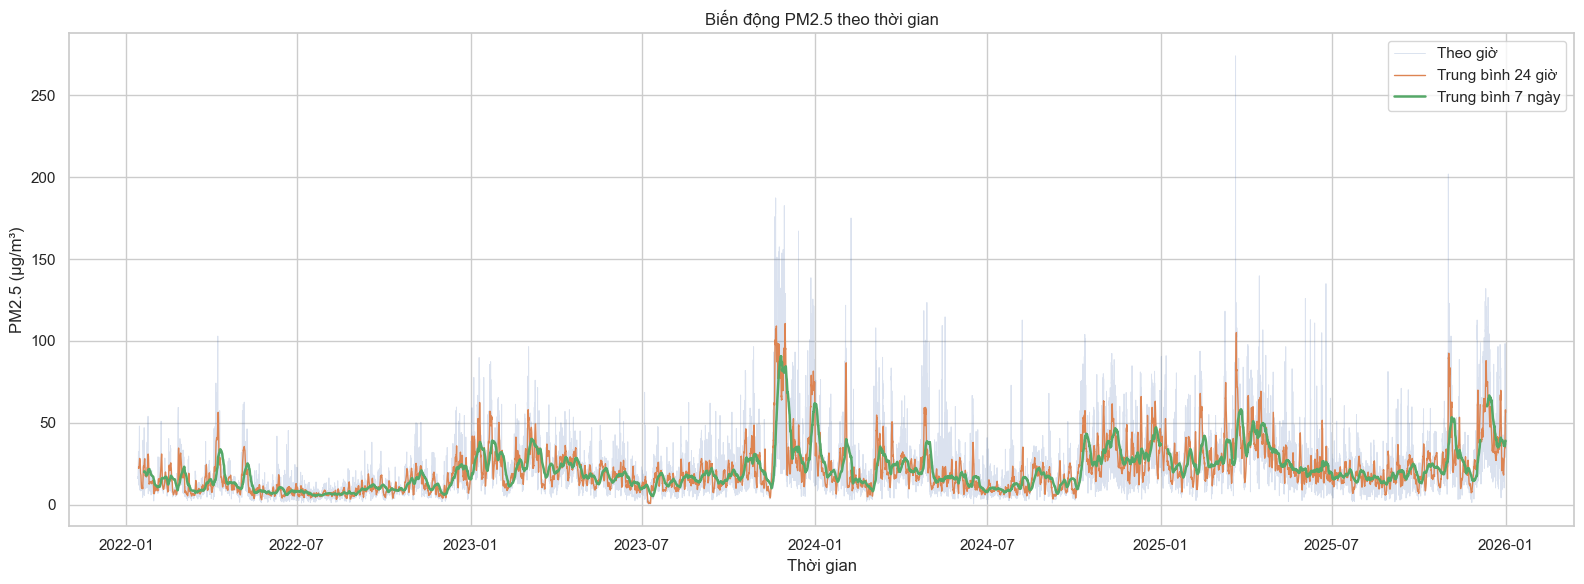

In [31]:
pm25_ts = df_clean.set_index("Local Time")["PM25"]
plt.figure(figsize=(16, 6))
plt.plot(pm25_ts.index, pm25_ts, alpha=0.20, linewidth=0.7, label="Theo giờ")
plt.plot(pm25_ts.index, pm25_ts.rolling(24).mean(), linewidth=1, label="Trung bình 24 giờ")
plt.plot(pm25_ts.index, pm25_ts.rolling(24 * 7).mean(), linewidth=1.8, label="Trung bình 7 ngày")
plt.title("Biến động PM2.5 theo thời gian")
plt.xlabel("Thời gian"); plt.ylabel("PM2.5 (µg/m³)"); plt.legend()
plt.tight_layout(); plt.show()

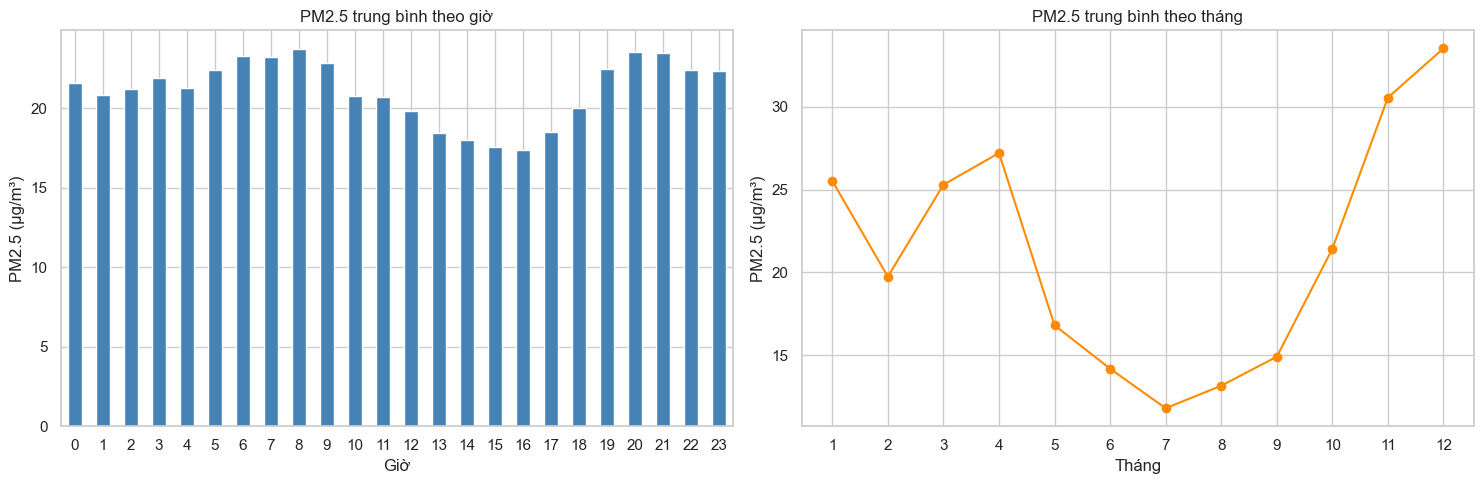

Giờ cao nhất: 8 giờ (23.70 µg/m³)
Tháng cao nhất: tháng 12 (33.52 µg/m³)


In [32]:
df_eda = df_clean.copy()
df_eda["Hour"] = df_eda["Local Time"].dt.hour
df_eda["Month"] = df_eda["Local Time"].dt.month
hourly_pm25 = df_eda.groupby("Hour")["PM25"].mean()
monthly_pm25 = df_eda.groupby("Month")["PM25"].mean()
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
hourly_pm25.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set(title="PM2.5 trung bình theo giờ", xlabel="Giờ", ylabel="PM2.5 (µg/m³)")
axes[0].tick_params(axis="x", rotation=0)
monthly_pm25.plot(marker="o", ax=axes[1], color="darkorange")
axes[1].set(title="PM2.5 trung bình theo tháng", xlabel="Tháng", ylabel="PM2.5 (µg/m³)")
axes[1].set_xticks(range(1, 13))
plt.tight_layout(); plt.show()
print(f"Giờ cao nhất: {hourly_pm25.idxmax()} giờ ({hourly_pm25.max():.2f} µg/m³)")
print(f"Tháng cao nhất: tháng {monthly_pm25.idxmax()} ({monthly_pm25.max():.2f} µg/m³)")

## 8. PM2.5 và các yếu tố khí tượng

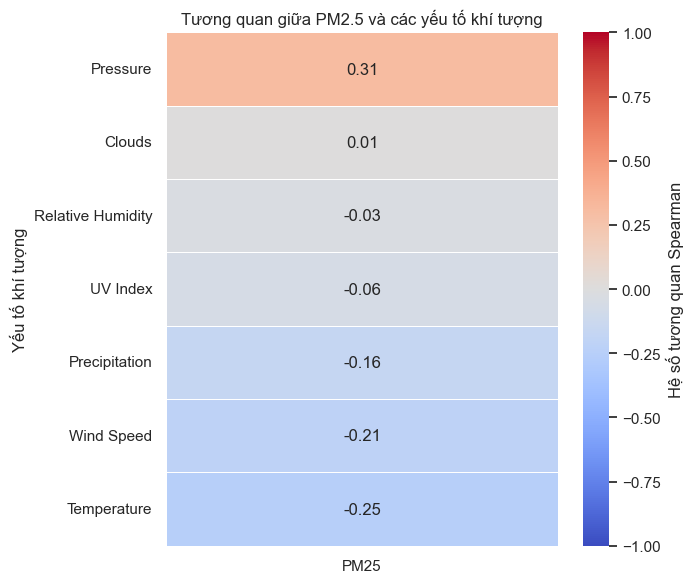

,PM25
Pressure,0.31
Clouds,0.01
Relative Humidity,-0.03
UV Index,-0.06
Precipitation,-0.16
Wind Speed,-0.21
Temperature,-0.25


In [33]:
weather_cols = ["Clouds", "Precipitation", "Pressure", "Relative Humidity", "Temperature", "UV Index", "Wind Speed"]
weather_corr = (df_eda[["PM25"] + weather_cols].corr(method="spearman")[["PM25"]]
                .drop(index="PM25").sort_values("PM25", ascending=False))
plt.figure(figsize=(7, 6))
sns.heatmap(weather_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, linewidths=0.5, cbar_kws={"label": "Hệ số tương quan Spearman"})
plt.title("Tương quan giữa PM2.5 và các yếu tố khí tượng")
plt.xlabel(""); plt.ylabel("Yếu tố khí tượng")
plt.tight_layout(); plt.show()
display(weather_corr.round(2))

## 9. Nội dung lấy vào báo cáo

1. Quy mô và phạm vi thời gian.
2. Bảng kiểu dữ liệu và `describe()`.
3. Giá trị thiếu, timestamp trùng và timestamp bị thiếu.
4. Bảng so sánh trước/sau xử lý.
5. Histogram và boxplot PM2.5.
6. PM2.5 theo thời gian, giờ và tháng.
7. Heatmap tương quan khí tượng.

Sau mỗi bảng/hình: nêu mục đích → kết quả → nhận xét → ý nghĩa cho bước tiếp theo.